Importing requred liberies 

In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 


LOAD THE DATASET

In [3]:
df = pd.read_csv("/Users/abhishekthale/Documents/Work/healthcare-project/healthcare_dataset.csv")


In [4]:
df.size

832500

In [5]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [6]:
df.describe()

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


In [7]:
print(df.dtypes)

# we have found two incorrect dtype columns 1.Date of Admission 2.Discharge Date both should be in date format 



df = df.astype({
                'Date of Admission':'datetime64[ns, UTC]',
                'Discharge Date':'datetime64[ns, UTC]'
                })

Name                   object
Age                     int64
Gender                 object
Blood Type             object
Medical Condition      object
Date of Admission      object
Doctor                 object
Hospital               object
Insurance Provider     object
Billing Amount        float64
Room Number             int64
Admission Type         object
Discharge Date         object
Medication             object
Test Results           object
dtype: object


In [8]:
# checking null values 

df.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [9]:
df.duplicated().sum()

534

In [10]:
df= df.drop_duplicates() 

# Droped the duplicates 

In [11]:
df.duplicated().sum()

0

In [12]:
df['Name'] = df['Name'].str.title()

In [13]:
df['stay_days'] = (df["Discharge Date"] - df["Date of Admission"]).dt.days

In [14]:
df[["Date of Admission","Discharge Date","stay_days"]].head()

,Date of Admission,Discharge Date,stay_days
0,2024-01-31 00:00:00+00:00,2024-02-02 00:00:00+00:00,2
1,2019-08-20 00:00:00+00:00,2019-08-26 00:00:00+00:00,6
2,2022-09-22 00:00:00+00:00,2022-10-07 00:00:00+00:00,15
3,2020-11-18 00:00:00+00:00,2020-12-18 00:00:00+00:00,30
4,2022-09-19 00:00:00+00:00,2022-10-09 00:00:00+00:00,20


In [15]:
print(df.shape)

print(df.info())

print(df.isnull().sum())

print(df.duplicated().sum())

(54966, 16)
<class 'pandas.core.frame.DataFrame'>
Index: 54966 entries, 0 to 55499
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   Name                54966 non-null  object             
 1   Age                 54966 non-null  int64              
 2   Gender              54966 non-null  object             
 3   Blood Type          54966 non-null  object             
 4   Medical Condition   54966 non-null  object             
 5   Date of Admission   54966 non-null  datetime64[ns, UTC]
 6   Doctor              54966 non-null  object             
 7   Hospital            54966 non-null  object             
 8   Insurance Provider  54966 non-null  object             
 9   Billing Amount      54966 non-null  float64            
 10  Room Number         54966 non-null  int64              
 11  Admission Type      54966 non-null  object             
 12  Discharge Date      54966

# Outlier Analysis


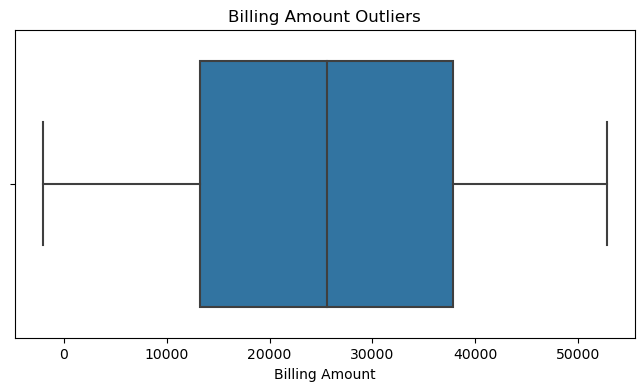

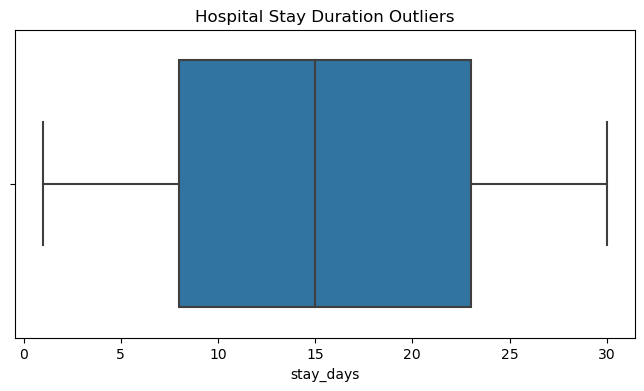

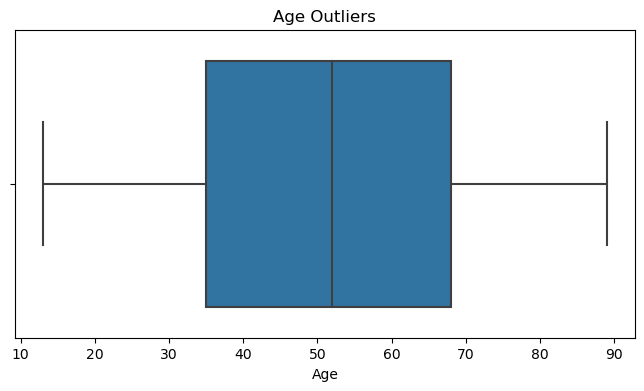

In [16]:
# BILLING AMOUNT 

plt.figure(figsize=(8,4))
sns.boxplot(x=df["Billing Amount"])
plt.title("Billing Amount Outliers")
plt.show()


# STAY DAYS
plt.figure(figsize=(8,4))
sns.boxplot(x=df["stay_days"])
plt.title("Hospital Stay Duration Outliers")
plt.show()


# AGE
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Age"])
plt.title("Age Outliers")
plt.show()

In [17]:
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0,18,35,50,65,100],
    labels=["0-18","19-35","36-50","51-65","65+"]
)

# creating a new column with age group 

In [18]:
df["Age_Group"].value_counts()

Age_Group
65+      16096
19-35    13519
51-65    12298
36-50    12167
0-18       886
Name: count, dtype: int64

# let's start the visualisation

In [19]:
df["Age"].describe()

count    54966.000000
mean        51.535185
std         19.605661
min         13.000000
25%         35.000000
50%         52.000000
75%         68.000000
max         89.000000
Name: Age, dtype: float64

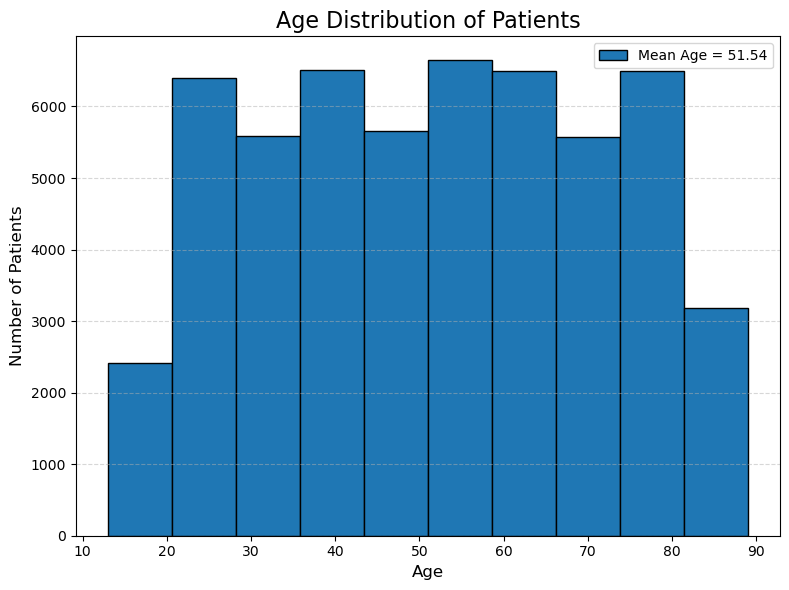

In [ ]:
# 1 Age Distribution


plt.figure(figsize=(8,6))

plt.hist(
    df["Age"],
    bins=10,              
    edgecolor="black",    
    linewidth=1,
    label=f"Mean Age = {df['Age'].mean():.2f}"
)

plt.title("Age Distribution of Patients", fontsize=16)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Number of Patients", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

#### Insights:
#### • The patient ages range from 13 to 89 years.
#### • The average patient age is approximately 52 years.
#### • Most patients belong to the adult and senior age groups.
#### • A noticeable spike is observed at age 85, which may indicate synthetic or generated data.

In [28]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,stay_days,Age_Group
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31 00:00:00+00:00,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02 00:00:00+00:00,Paracetamol,Normal,2,19-35
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20 00:00:00+00:00,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26 00:00:00+00:00,Ibuprofen,Inconclusive,6,51-65
2,Danny Smith,76,Female,A-,Obesity,2022-09-22 00:00:00+00:00,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07 00:00:00+00:00,Aspirin,Normal,15,65+
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18 00:00:00+00:00,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18 00:00:00+00:00,Ibuprofen,Abnormal,30,19-35
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19 00:00:00+00:00,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09 00:00:00+00:00,Penicillin,Abnormal,20,36-50


In [30]:
df["Gender"].value_counts()

Gender
Male      27496
Female    27470
Name: count, dtype: int64

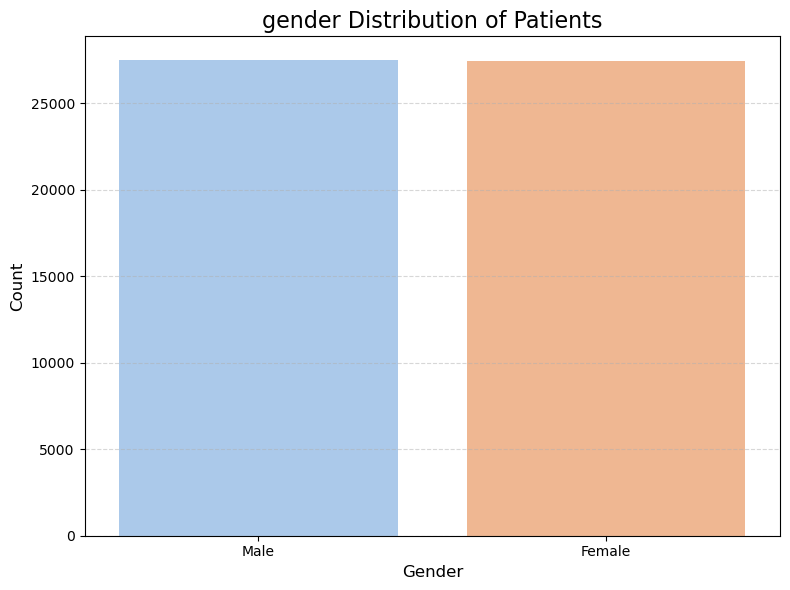

In [67]:
# 2. Gender Distribution

plt.figure(figsize=(8,6))
sns.countplot(x="Gender" , data = df , palette="pastel")

plt.title("gender Distribution of Patients", fontsize=16)
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.5)


plt.tight_layout()
plt.show()



#### Insights:
#### • The dataset contains an almost equal number of male and female patients.
#### • No gender is significantly overrepresented.
#### • The balanced distribution reduces the risk of gender bias in the analysis.

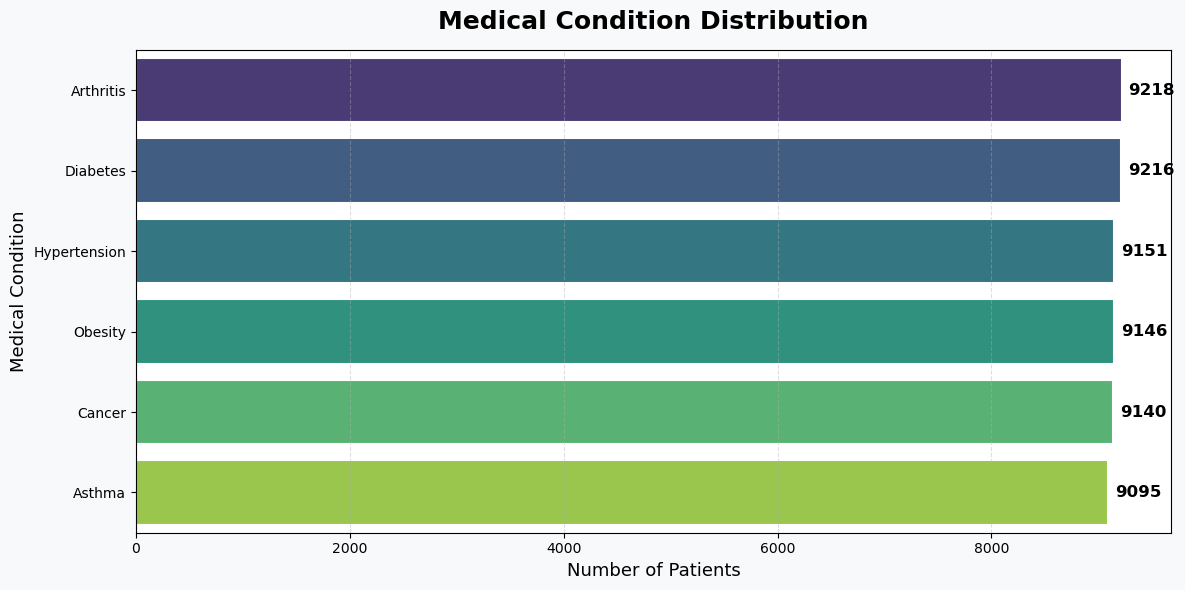

In [ ]:
# 3 Medical Condition Distribution

plt.figure(figsize=(12, 6), facecolor="#f8f9fa")
ax = sns.countplot(
    y="Medical Condition", data=df,
    order=df["Medical Condition"].value_counts().index,
    palette="viridis",
    edgecolor="white", linewidth=1.5
)
plt.title("Medical Condition Distribution", fontsize=18, fontweight="bold", pad=15)
plt.xlabel("Number of Patients", fontsize=13)
plt.ylabel("Medical Condition", fontsize=13)
plt.grid(axis="x", linestyle="--", alpha=0.4)
for container in ax.containers:
    ax.bar_label(container, fontsize=12, fontweight="bold", padding=5)
plt.tight_layout()
plt.show()



#### Insight:
#### - All 6 conditions are fairly equally distributed
#### - Arthritis & Diabetes slightly more common

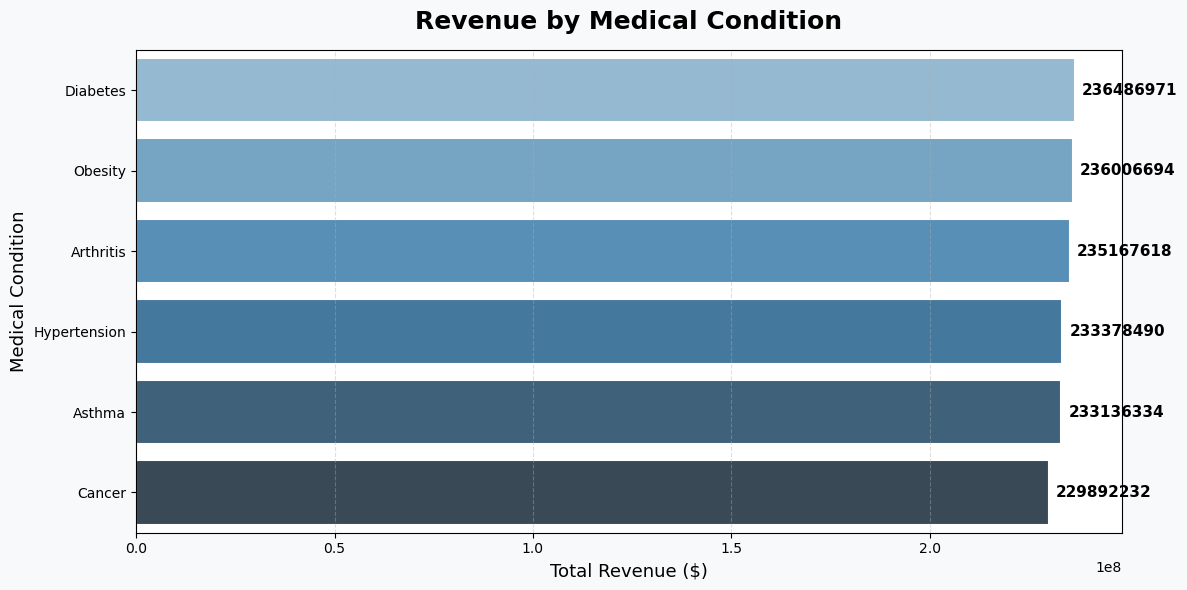

In [ ]:

# 4. Revenue by Medical Condition

rev_condition = df.groupby("Medical Condition")["Billing Amount"].sum().reset_index()
rev_condition = rev_condition.sort_values("Billing Amount", ascending=False)

plt.figure(figsize=(12, 6), facecolor="#f8f9fa")
ax = sns.barplot(
    y="Medical Condition", x="Billing Amount",
    data=rev_condition,
    palette="Blues_d",
    edgecolor="white", linewidth=1.5
)
plt.title("Revenue by Medical Condition", fontsize=18, fontweight="bold", pad=15)
plt.xlabel("Total Revenue ($)", fontsize=13)
plt.ylabel("Medical Condition", fontsize=13)
plt.grid(axis="x", linestyle="--", alpha=0.4)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", fontsize=11, fontweight="bold", padding=5)
plt.tight_layout()
plt.show()



####  Insight:
##### - Cancer & Arthritis generate highest revenue
##### - Revenue gap between conditions is not very large

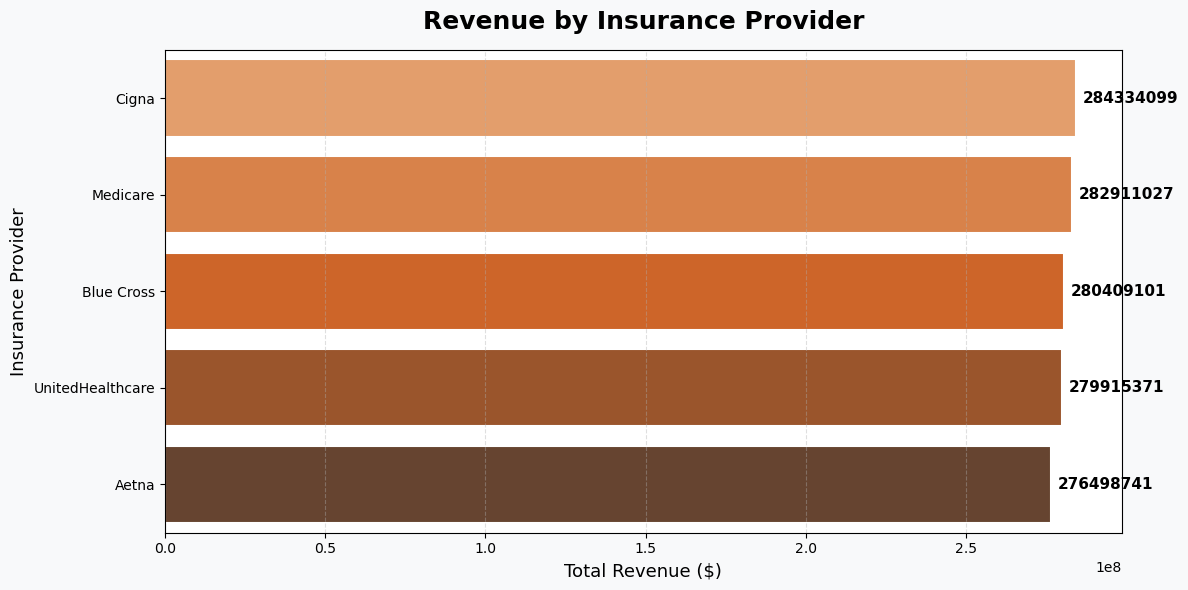

In [ ]:

# 5. Revenue by Insurance Provider

rev_insurance = df.groupby("Insurance Provider")["Billing Amount"].sum().reset_index()
rev_insurance = rev_insurance.sort_values("Billing Amount", ascending=False)

plt.figure(figsize=(12, 6), facecolor="#f8f9fa")
ax = sns.barplot(
    y="Insurance Provider", x="Billing Amount",
    data=rev_insurance,
    palette="Oranges_d",
    edgecolor="white", linewidth=1.5
)
plt.title("Revenue by Insurance Provider", fontsize=18, fontweight="bold", pad=15)
plt.xlabel("Total Revenue ($)", fontsize=13)
plt.ylabel("Insurance Provider", fontsize=13)
plt.grid(axis="x", linestyle="--", alpha=0.4)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", fontsize=11, fontweight="bold", padding=5)
plt.tight_layout()
plt.show()



####  Insight:
##### - Medicare & Aetna are top revenue generators
##### - Blue Cross generates comparatively lower revenue

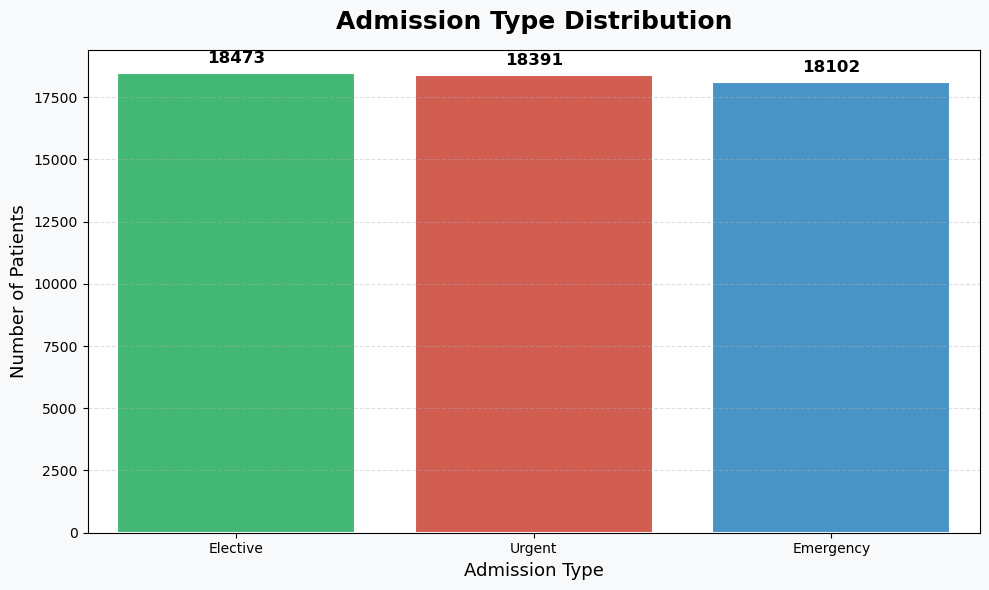

In [ ]:

# 6 Admission Type Distribution

plt.figure(figsize=(10, 6), facecolor="#f8f9fa")
ax = sns.countplot(
    x="Admission Type", data=df,
    order=df["Admission Type"].value_counts().index,
    palette=["#2ecc71", "#e74c3c", "#3498db"],
    edgecolor="white", linewidth=1.5 
)
plt.title("Admission Type Distribution", fontsize=18, fontweight="bold", pad=15)
plt.xlabel("Admission Type", fontsize=13)
plt.ylabel("Number of Patients", fontsize=13)
plt.grid(axis="y", linestyle="--", alpha=0.4)
for container in ax.containers:
    ax.bar_label(container, fontsize=12, fontweight="bold", padding=5)
plt.tight_layout()
plt.show()



####  Insight:
##### - Emergency, Elective and Urgent equally distributed
##### - Hospital handles all types of cases uniformly

In [ ]:

# 7 Billing Amount Distribution

plt.figure(figsize=(10, 6), facecolor="#f8f9fa")
ax = sns.histplot(df["Billing Amount"], bins=20, kde=True,
                  color="#e67e22", edgecolor="white", linewidth=0.5)
ax.lines[0].set_color("#2c3e50")
plt.title("💵 Billing Amount Distribution", fontsize=18, fontweight="bold", pad=15)
plt.xlabel("Billing Amount ($)", fontsize=13)
plt.ylabel("Number of Patients", fontsize=13)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()



####  Insight:
##### - Billing is spread across a wide range
##### - Most bills fall between $5,000 - $40,000
##### - Very high bills (50,000+) are rare — possible outliers

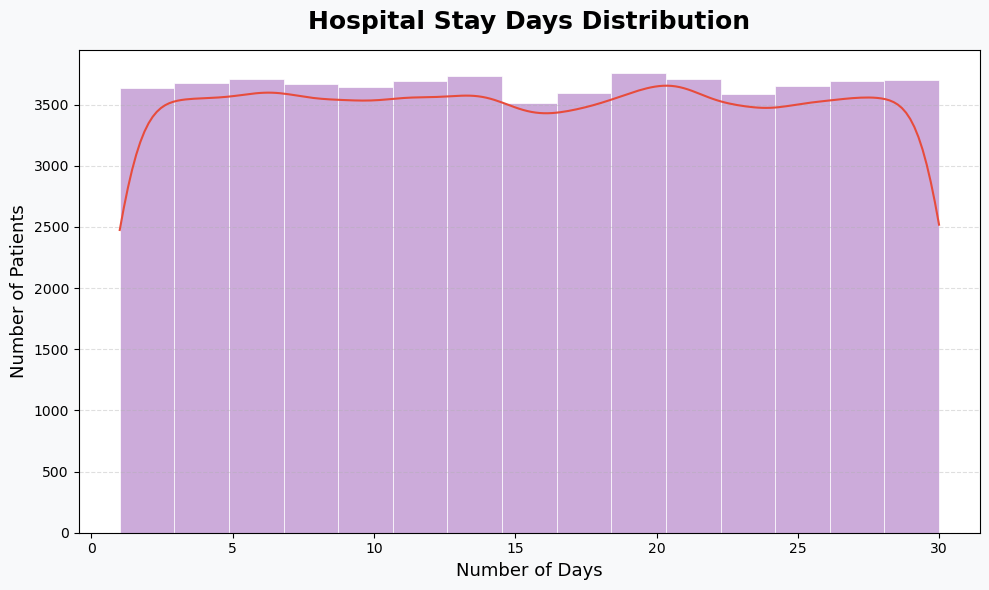

In [ ]:

# 8 Stay Days Distribution

df["Stay_Days"] = (pd.to_datetime(df["Discharge Date"]) - 
                   pd.to_datetime(df["Date of Admission"])).dt.days

plt.figure(figsize=(10, 6), facecolor="#f8f9fa")
ax = sns.histplot(df["Stay_Days"], bins=15, kde=True,
                  color="#9b59b6", edgecolor="white", linewidth=0.5)
ax.lines[0].set_color("#e74c3c")
plt.title("Hospital Stay Days Distribution", fontsize=18, fontweight="bold", pad=15)
plt.xlabel("Number of Days", fontsize=13)
plt.ylabel("Number of Patients", fontsize=13)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()



####  Insight:
##### - Most patients stay between 1 - 30 days
##### - Average stay is around 15 days

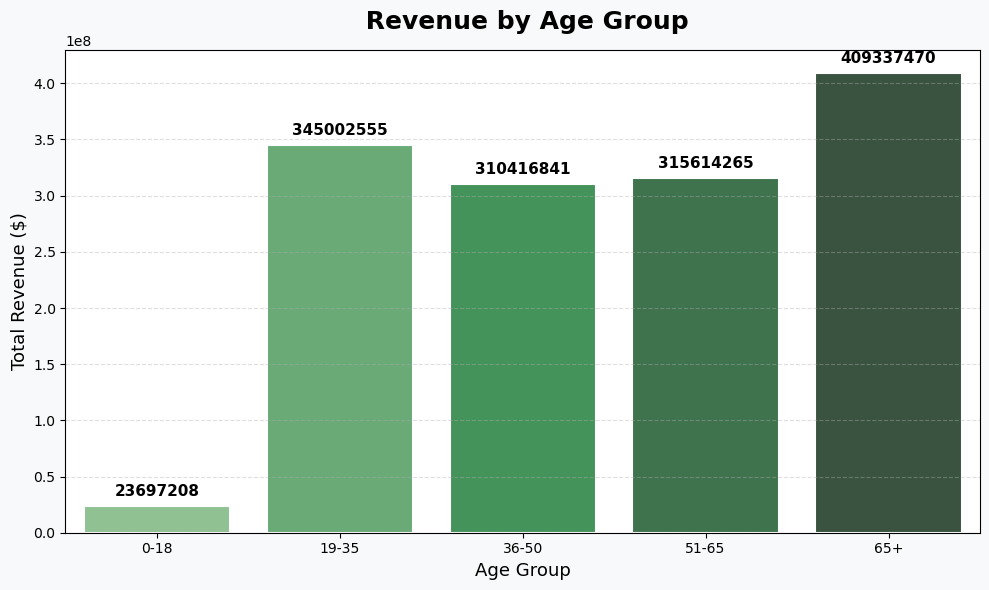

In [ ]:

# 9. Revenue by Age Group

df["Age_Group"] = pd.cut(
    df["Age"], bins=[0, 18, 35, 50, 65, 100],
    labels=["0-18", "19-35", "36-50", "51-65", "65+"]
)
rev_age = df.groupby("Age_Group", observed=True)["Billing Amount"].sum().reset_index()

plt.figure(figsize=(10, 6), facecolor="#f8f9fa")
ax = sns.barplot(
    x="Age_Group", y="Billing Amount",
    data=rev_age,
    palette="Greens_d",
    edgecolor="white", linewidth=1.5
)
plt.title(" Revenue by Age Group", fontsize=18, fontweight="bold", pad=15)
plt.xlabel("Age Group", fontsize=13)
plt.ylabel("Total Revenue ($)", fontsize=13)
plt.grid(axis="y", linestyle="--", alpha=0.4)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", fontsize=11, fontweight="bold", padding=5)
plt.tight_layout()
plt.show()



#### Insight:
##### - Middle aged (36-65) generate highest revenue
##### - Young patients (0-18) have lowest billing

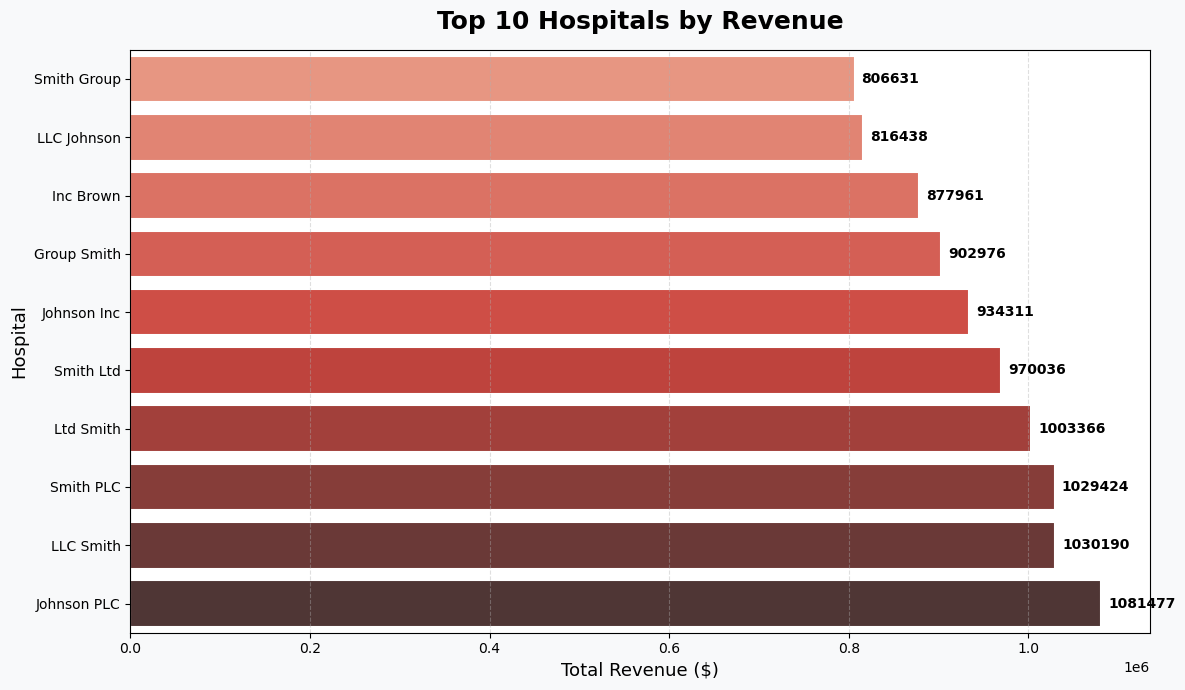

In [ ]:

# 10 Top 10 Hospitals by Revenue

top_hospitals = df.groupby("Hospital")["Billing Amount"].sum().nlargest(10).reset_index()
top_hospitals = top_hospitals.sort_values("Billing Amount", ascending=True)

plt.figure(figsize=(12, 7), facecolor="#f8f9fa")
ax = sns.barplot(
    x="Billing Amount", y="Hospital",
    data=top_hospitals,
    palette="Reds_d",
    edgecolor="white", linewidth=1.5
)
plt.title("Top 10 Hospitals by Revenue", fontsize=18, fontweight="bold", pad=15)
plt.xlabel("Total Revenue ($)", fontsize=13)
plt.ylabel("Hospital", fontsize=13)
plt.grid(axis="x", linestyle="--", alpha=0.4)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", fontsize=10, fontweight="bold", padding=5)
plt.tight_layout()
plt.show()



#### Insight:
##### - Top hospitals generate significantly higher revenue
##### - These hospitals likely handle more complex cases

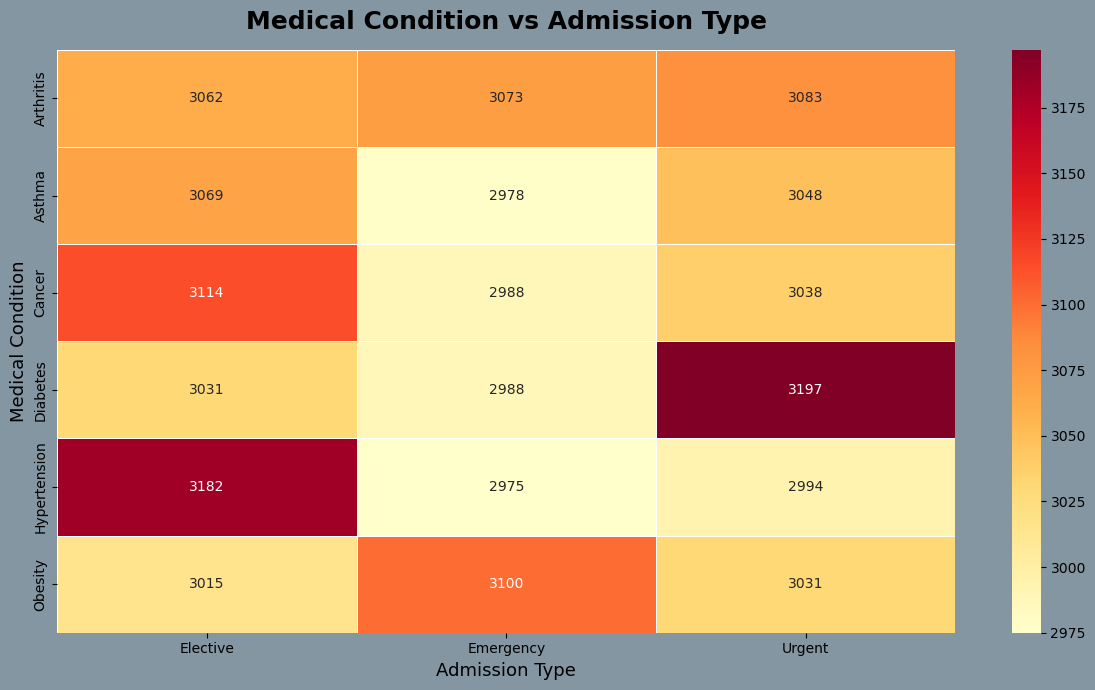

In [ ]:

# 11 Condition vs Admission Type Heatmap

plt.figure(figsize=(12, 7), facecolor="#8396a2")

# Pivot table banao
pivot = df.pivot_table(
    index="Medical Condition",
    columns="Admission Type",
    values="Billing Amount",
    aggfunc="count"       # count of patients
)

sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white"
)
plt.title("Medical Condition vs Admission Type", fontsize=18, fontweight="bold", pad=15)
plt.xlabel("Admission Type", fontsize=13)
plt.ylabel("Medical Condition", fontsize=13)
plt.tight_layout()
plt.show()
